In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
precision_score,recall_score,f1_score,
confusion_matrix,classification_report,roc_auc_score,roc_curve)


In [5]:
df = pd.read_csv('hospital_readmissions_30k.csv')

In [6]:
print(df.shape)

(30000, 12)


In [7]:
df.head(20)

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
5,6,75,Female,139/100,194,33.5,No,Yes,0,10,Home,No
6,7,47,Male,139/79,168,27.1,No,Yes,5,8,Home,No
7,8,18,Other,153/81,210,26.3,No,No,5,2,Home,No
8,9,68,Male,111/76,218,30.4,No,Yes,3,8,Home,No
9,10,23,Female,142/72,186,21.3,No,No,3,3,Home,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [9]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol,0
bmi,0
diabetes,0
hypertension,0
medication_count,0
length_of_stay,0


In [10]:
df["readmitted_30_days"].value_counts()

,count
readmitted_30_days,
No,26326
Yes,3674


In [11]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [13]:
print(df.shape)

(30000, 12)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [18]:
X = df.drop(columns=[ "readmitted_30_days"],axis=1)
y = df["readmitted_30_days"]

In [19]:
print(X.shape)
print(y.shape)

(30000, 11)
(30000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
numeric_cols = X_train.select_dtypes(include="number").columns
categorical_cols = X_train.select_dtypes(include="object").columns

# print("Numeric columns:", list(numeric_cols))
# print("Categorical columns:", list(categorical_cols))

In [22]:
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [23]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

In [24]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_num, X_train_cat])
X_test_final = hstack([X_test_num, X_test_cat])

print(X_train_final.shape)
print(X_test_final.shape)

(24000, 1597)
(6000, 1597)


In [25]:
model = LogisticRegression(penalty = "l2")

In [26]:
model.fit(X_train_final,y_train)

LogisticRegression()

In [27]:
y_predict=model.predict(X_test_final)

In [28]:
print(y_predict)

['No' 'No' 'No' ... 'No' 'No' 'No']


In [29]:
print(accuracy_score(y_test,y_predict))

0.8718333333333333


In [30]:
classification_report(y_test,y_predict)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n          No       0.87      1.00      0.93      5231\n         Yes       0.00      0.00      0.00       769\n\n    accuracy                           0.87      6000\n   macro avg       0.44      0.50      0.47      6000\nweighted avg       0.76      0.87      0.81      6000\n'

In [31]:
confusion_matrix(y_test,y_predict)

array([[5231,    0],
       [ 769,    0]])

In [32]:
y_prob = model.predict_proba(X_test_final)[:, 1]

In [37]:
print("Precision:", precision_score(y_test, y_predict, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_predict, pos_label='Yes'))
print("F1 Score:", f1_score(y_test, y_predict, pos_label='Yes'))

# Convert y_test to numerical labels for roc_auc_score
y_test_numerical = y_test.apply(lambda x: 1 if x == 'Yes' else 0)
print("ROC-AUC:", roc_auc_score(y_test_numerical, y_prob))

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5420655445343219


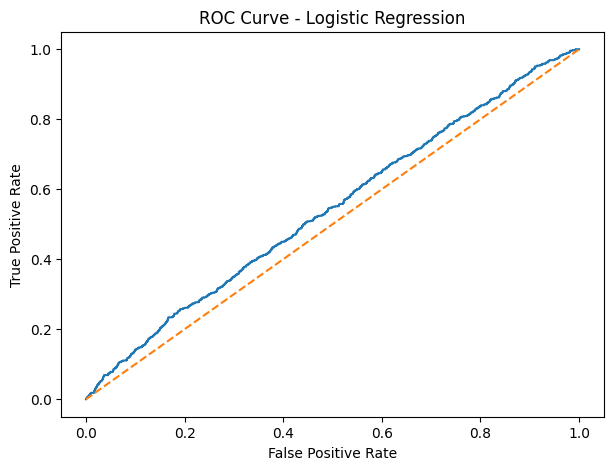

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()